### If you get an error here, it means you need to run the prepare_data.ipynb file first

In [1]:
import json
import numpy as np
import pandas as pd

from rnanorm import TMM
from pathlib import Path


description_path = Path('description.json')
if not description_path.exists():
    raise FileNotFoundError(
        "description.json not found. Please run 'prepare_data.ipynb' first to generate it."
    )

with open(description_path) as f:
    data = json.load(f)


## Preprocessing steps

1. **Load data** — Read the dataset and split columns into clinical variables and raw gene-level counts.

2. **Robust-expression filter (defined on raw counts)** — Keep genes with the 75th percentile of raw counts across samples \(\ge 100\) (i.e., expressed at \(\ge 100\) counts in at least 25% of samples).

3. **TMM normalization** — Apply TMM to the full gene count matrix to compute normalization factors correcting for library size and RNA composition; obtain normalized counts.

4. **Apply gene filter and log-transform** — Subset to the robustly expressed genes and apply \(\log(x+1)\).

5. **Z-score standardization** — For each gene, center and scale across samples to mean 0 and standard deviation 1.

In [2]:
data_file_name = data['data_file_names'][0]

num_clinical_features = data['data_summary']['clinical_features']

df = pd.read_csv(data_file_name)


clinical_cols = df.columns[:num_clinical_features]
gene_cols = df.columns[num_clinical_features:]

raw_counts = df[gene_cols]
print('Before preprocessing:\n - n_genes: %d' % (df[gene_cols].shape[1]))

# create mask of robustly expressed genes
robus_genes_mask = np.percentile(df[gene_cols], 75, axis=0) >= 100

# normalize counts
df[gene_cols] = TMM().set_output(transform="pandas").fit_transform(df[gene_cols])

# apply robust gene mask
gene_cols = df[gene_cols].columns[robus_genes_mask].tolist()
df = df[list(clinical_cols) + gene_cols]

# # log transform and standardize (genes only)
df[gene_cols] = np.log(df[gene_cols] + 1)
df[gene_cols] = (df[gene_cols] - df[gene_cols].mean(axis=0)) / df[gene_cols].std(axis=0)

print("\nAfter preprocessing:\n - n_genes: %d" % (df[gene_cols].shape[1]))

transformed_data_file_name = data_file_name.replace("original", "preprocessed")
df.to_csv(transformed_data_file_name, index=False)

# update description.json file 
if transformed_data_file_name not in data['data_file_names']:
    data['data_file_names'].append(transformed_data_file_name)

with open(description_path, 'w') as f:
    json.dump(data, f, indent=4)


Before preprocessing:
 - n_genes: 58232


/Users/jakakokosar/dev/phd/review-paper/.venv/lib/python3.12/site-packages/rnanorm/methods/between_sample.py:101: RuntimeWarning: divide by zero encountered in divide
  factors = factors / self.geometric_mean_
/Users/jakakokosar/dev/phd/review-paper/.venv/lib/python3.12/site-packages/rnanorm/methods/between_sample.py:101: RuntimeWarning: invalid value encountered in divide
  factors = factors / self.geometric_mean_



After preprocessing:
 - n_genes: 12427


## Below is the code for generation sample file.

**Insetad of randomly selecting 100 genes, we do extra steps; we test for association between each gene and survival (using univariate Cox regression) and select top 100.**

Even if dataset contains multiple survival endpoints, we default to OS (Overall Survival). If the dataset does not contain OS, we select the first one in the list (see `survival-endpoints` in `description.json` file) that is available.


In [3]:
from tqdm import tqdm
from lifelines import CoxPHFitter
from statsmodels.stats.multitest import multipletests

from joblib import Parallel, delayed

endpoints = data["survival-endpoints"]
ordered = [e for e in endpoints if e["abbrv"] == "OS"] + [e for e in endpoints if e["abbrv"] != "OS"]
for endpoint in ordered:
    time_col_name = endpoint["time_var"]["var_name"]
    event_col_name = endpoint["event_var"]["var_name"]
    
    if time_col_name != "unknown" and event_col_name != "unknown" and time_col_name in df.columns and event_col_name in df.columns:
        time_col, event_col = time_col_name, event_col_name
        endpoint_abbrv = endpoint["abbrv"]
        break
else:
    raise ValueError("No available survival endpoint")


all_time_cols = []
all_event_cols = []
for endpoint in endpoints:
    endpoint_time = endpoint["time_var"]["var_name"]
    endpoint_event = endpoint["event_var"]["var_name"]

    if endpoint_time != "unknown" and endpoint_time in df.columns:
        all_time_cols.append(endpoint_time)
    if endpoint_event != "unknown" and endpoint_event in df.columns:
        all_event_cols.append(endpoint_event)

all_time_cols = list(dict.fromkeys(all_time_cols))
all_event_cols = list(dict.fromkeys(all_event_cols))
all_survival_cols = all_time_cols + [c for c in all_event_cols if c not in all_time_cols]

df_ = df.copy()

df_[time_col] = pd.to_numeric(df_[time_col])
df_[event_col] = pd.to_numeric(df_[event_col])


for extra_time_col in all_time_cols:
    df_[extra_time_col] = pd.to_numeric(df_[extra_time_col])
for extra_event_col in all_event_cols:
    df_[extra_event_col] = pd.to_numeric(df_[extra_event_col])

n_rows_before = len(df_)
df_ = df_.dropna(subset=[time_col, event_col])
n_rows_after = len(df_)

if n_rows_before > n_rows_after:
    print(f"Warning: {n_rows_before - n_rows_after} rows dropped due to missing survival data\n\n")


gene_matrix = df_[gene_cols].to_numpy()
time_vals = df_[time_col].to_numpy()
event_vals = df_[event_col].to_numpy()
gene_names = np.array(gene_cols)

def _process_one_gene(i):
    gene_vals = gene_matrix[:, i]
    tmp = pd.DataFrame({
        "T": time_vals,
        "E": event_vals,
        "gene": gene_vals,
    })
    cph = CoxPHFitter()
    cph.fit(tmp, duration_col="T", event_col="E", show_progress=False)
    summary = cph.summary.loc["gene"]
    return {
        "gene": gene_names[i],
        "pvalue": summary["p"],
        "test_stat": summary["z"],
    }

results = Parallel(n_jobs=8, backend="loky")(
    delayed(_process_one_gene)(i) for i in tqdm(range(len(gene_names)))
)

results_df = pd.DataFrame(results)

results_df["fdr_pvalue"] = multipletests(
    results_df["pvalue"], method="fdr_bh"
)[1]

results_df = results_df.sort_values("pvalue")

top_genes = results_df.head(100)["gene"].tolist()

sample_file_name = transformed_data_file_name.replace(".csv", "_sample.csv")
df_ = df_[all_survival_cols + top_genes]
df_.to_csv(sample_file_name, index=False)

if sample_file_name not in data["data_file_names"]:
    data["data_file_names"].append(sample_file_name)

with open(description_path, "w") as f:
    json.dump(data, f, indent=4)

results_df

100%|██████████| 12427/12427 [00:16<00:00, 763.88it/s]


,gene,pvalue,test_stat,fdr_pvalue
4859,BUD31,0.000715,3.383587,0.999953
7030,COLCA1,0.000953,-3.303933,0.999953
6531,STK33,0.002030,-3.085873,0.999953
8268,CCDC92,0.002327,-3.044995,0.999953
799,NPR1,0.002405,-3.035064,0.999953
...,...,...,...,...
7215,MINDY3,1.000000,0.000000,1.000000
6063,POLR1E,1.000000,0.000000,1.000000
6875,MRPL21,1.000000,0.000000,1.000000
4671,EPDR1,1.000000,0.000000,1.000000


## Here we show the survival curves for the top and bottom gene based on our analysis


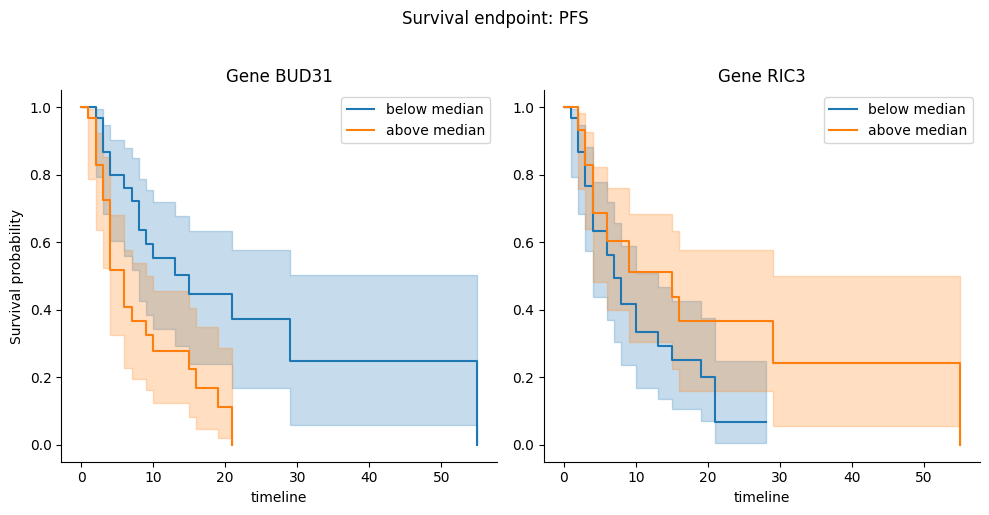

In [4]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

genes = [
    results_df.sort_values("pvalue").iloc[0]["gene"],
    results_df.sort_values("pvalue").iloc[99]["gene"],
]
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, gene in zip(axes, genes):
    low = df_[gene] <= df_[gene].median()
    high = df_[gene] > df_[gene].median()
    km_low = KaplanMeierFitter().fit(df_.loc[low, time_col], df_.loc[low, event_col])
    km_high = KaplanMeierFitter().fit(df_.loc[high, time_col], df_.loc[high, event_col])
    km_low.plot_survival_function(ax=ax, label="below median")
    km_high.plot_survival_function(ax=ax, label="above median")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(f"Gene {gene}")
axes[0].set_ylabel("Survival probability")
fig.suptitle(f"Survival endpoint: {endpoint_abbrv}", y=1.02)
plt.tight_layout()


In [5]:
# Metadata for samples above vs below median (top gene from survival analysis)
top_gene = results_df.sort_values("pvalue").iloc[0]["gene"]
median_val = df_[top_gene].median()
below_median = df_[top_gene] <= median_val
above_median = df_[top_gene] > median_val

print("Below median: n =", below_median.sum())
display(df_.loc[below_median])

print("\nAbove median: n =", above_median.sum())
display(df_.loc[above_median])

Below median: n = 31


,"PFS time, months",Response status available,BUD31,COLCA1,STK33,CCDC92,NPR1,FAM135A,HK2,CYP4X1,...,HCP5,ST7-OT4,LIN9,DSC2,TMT1A,SLC34A2,INTS6,SNRPD3,SPOCK2,RIC3
0,6,1,-0.787360,0.124226,-1.786891,-1.826555,-1.538541,1.200841,0.964469,2.185966,...,0.082491,-0.743310,0.438266,1.339220,-0.801110,-1.227827,0.355651,0.499870,-1.183932,1.732545
1,4,0,-0.980016,1.348720,0.937885,0.295335,2.397165,-0.215618,-0.988440,1.265890,...,0.292586,1.309169,-0.496908,-0.884263,0.663266,0.782393,0.085457,-0.460874,0.380566,0.921172
2,3,1,-0.455400,-1.033224,0.552058,-1.159659,-0.780313,-0.347879,0.959688,-1.110621,...,-0.994364,-0.692536,0.416955,0.706724,-1.826582,-1.712594,0.087716,0.451778,-1.590600,-2.114142
3,3,1,-0.092767,-1.317567,0.256669,0.098976,1.627513,0.173915,0.322068,-1.433214,...,0.713000,-0.494308,-0.083963,0.136947,-0.035578,-0.063700,0.248086,-0.215574,0.747838,1.497737
6,31,0,-0.325293,2.313362,-0.232040,0.451409,-0.014790,-0.160595,-0.164083,0.483321,...,1.386039,0.187982,-0.027887,0.448044,-0.209173,-0.395654,0.085686,-0.624960,0.612800,0.794002
7,13,1,-0.094348,-0.617890,0.962076,0.281197,-0.017395,-0.767997,-0.860835,0.425206,...,-0.032810,1.057697,0.207759,-0.478559,-1.074331,0.789919,-0.342878,-0.755313,-1.062041,-0.654355
8,28,0,-0.396951,1.841486,0.777602,-0.175203,-0.287409,-0.677017,-0.903907,0.599423,...,0.337742,0.054982,0.228416,-0.661327,1.065623,-0.265711,-0.451385,-0.153394,-0.430795,-0.095872
12,12,0,-0.047415,0.201118,0.403038,1.428458,0.582547,-1.552073,0.170448,0.853023,...,0.403505,1.583527,-2.036132,-1.180180,0.730072,1.251492,-0.591668,-0.534438,0.847112,0.125515
15,7,0,-0.190749,0.837092,0.449483,0.061231,1.141225,-0.355282,-0.628227,0.467542,...,0.969272,-0.290300,0.302270,0.751649,-0.060652,-1.727202,-0.170248,0.571470,1.809677,-0.353328
17,55,1,-0.469005,1.807354,0.663538,2.680696,2.660227,-0.866006,-0.657414,0.841478,...,0.358136,0.964647,-0.591390,-0.909938,1.220825,1.592566,-0.188253,-0.544396,1.206695,0.617366



Above median: n = 30


,"PFS time, months",Response status available,BUD31,COLCA1,STK33,CCDC92,NPR1,FAM135A,HK2,CYP4X1,...,HCP5,ST7-OT4,LIN9,DSC2,TMT1A,SLC34A2,INTS6,SNRPD3,SPOCK2,RIC3
4,3,1,-0.016583,-0.037794,-0.293042,-0.160329,-0.388821,0.603658,0.043955,1.543126,...,0.913223,0.064688,0.134137,1.030589,0.034817,-0.239827,0.483945,-0.313418,-0.154866,0.158065
5,20,0,0.674268,0.426199,0.499054,-0.180043,-0.473782,0.605139,0.915299,0.250581,...,0.207242,-0.149664,0.798760,0.589471,0.680938,-0.648731,0.409987,0.721702,-0.247388,-0.130482
9,9,0,0.271266,-0.213757,0.175301,0.024093,-0.520587,-0.145299,1.452873,0.374357,...,-0.149953,0.876189,0.088932,1.166339,0.257704,-0.253195,-0.283699,0.634221,-0.934624,-0.527844
10,4,1,0.132327,0.089430,0.057197,-0.497069,-0.642553,1.768565,0.415361,-0.243987,...,-1.147945,-0.480974,0.456644,1.128527,0.078956,0.067549,0.044150,0.243670,-0.576742,0.777061
11,21,1,0.180738,-0.446714,-0.499213,0.609730,0.054685,-0.654516,-0.225960,1.755086,...,0.217221,-0.141246,0.072772,0.649212,-1.203010,-0.557857,-0.178306,0.553624,0.423304,-1.034731
13,4,1,2.001381,-2.397065,-2.404750,-1.237550,-2.102453,-0.391055,-1.666049,-1.935094,...,-3.554820,-2.710056,1.360160,-0.285187,-3.686075,-1.519028,-0.304313,-0.890027,-2.102116,-2.207771
14,16,1,0.009130,0.578367,0.880847,0.639807,0.349616,0.110547,-0.388216,-0.338139,...,0.191594,0.383626,0.150664,0.821526,0.322779,0.679801,0.178519,-0.617998,0.536282,0.911263
16,1,0,0.335382,-1.166907,0.736187,0.748684,0.736407,-0.493012,-0.372130,-0.508557,...,-0.491047,-0.171860,-0.108000,-0.189640,-0.251199,0.757457,-0.158232,0.496908,-0.646398,-1.350454
26,15,1,1.185146,0.515386,-0.264770,-0.586822,-0.059723,0.721413,-0.455532,-1.064437,...,-0.159988,-0.377855,0.326864,0.138086,-0.154350,-0.793246,0.739059,0.212033,-0.942274,-0.032512
27,2,1,0.488011,-0.020157,-0.395018,-0.096425,-0.845199,1.435816,1.134750,-0.209856,...,0.166612,-0.307889,0.406420,0.519830,-0.416889,0.527023,0.414283,1.077907,-1.606368,-1.377194
